# RR Robot - Dynamic model

In the following, we compute the dynamic model of the RR robot shown in the figure using `moro`.

<img src="img/rr_robot.svg">

First, we import the library:

In [3]:
from moro import *

Then, define the `Robot` instance using the DH parameters and joint types:

In [5]:
RR = Robot((l1,0,0,q1,"r"),
           (l2,0,0,q2,"r"))

Note that `qi` must be used as joint variables. In `moro`, only these variables are time-dependent. If you use `thetai` or another variable instead, when computing velocities the program will fail because it expects a time-dependent variable to compute the derivatives. Of course you can define your own time-dependent variable.

Next, define the dynamic parameters: masses, inertia tensors, the gravity vector, and the center-of-mass locations.

In [9]:
RR.masses = None
RR.inertia_tensors = None
RR.gravity = [0,-g,0] # in the negative y0 direction
rG11 = [-(l1-lc1),0,0] # CoM of link 1 w.r.t. frame {1}
rG22 = [-(l2-lc2),0,0] # CoM of link 2 w.r.t. frame {2}
RR.cm_positions = [rG11, rG22]

The dynamic model can be obtained using the `dynamic_model` method:

In [11]:
RR.dynamic_model()

This method returns a list of $n$ Euler-Lagrange equations:

$$ 
\frac{d}{dt}\left( \frac{\partial \mathcal{L}}{\partial \dot{q}_i} \right) - 
\frac{\partial \mathcal{L}}{\partial q_i} = \tau_i \qquad ; \quad 
\text{for }i=1,2,\cdots,n
$$

You can also compute the dynamic model in matrix form using `dynamic_model_matrix_form`

$$ 
\renewcommand{\vec}[1]{\mathbf{#1}}
M \ddot{\vec{q}} + C \dot{\vec{q}} + \vec{g} = \vec{\tau} 
$$

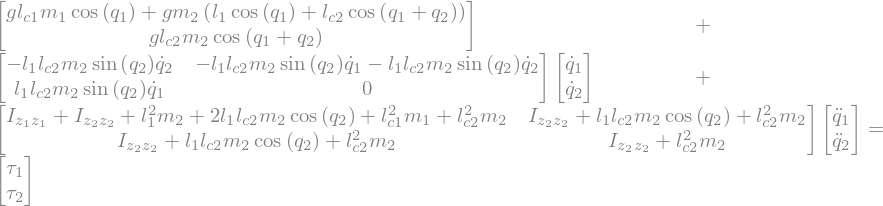

In [17]:
RR.dynamic_model_matrix_form()